# Неделя 4 — Эксперимент A/B/C

Карточка недели: `docs/week4_experiment.md` · Полное описание: тетрадь, раздел 8

**Конвенция ячеек:**
- ячейка без пометки — готовый код, просто запустите
- `# TODO:` — здесь пишете вы

In [1]:
import sys

import numpy as np
import pandas as pd

sys.path.append('..')
from src.validation import bootstrap_auc_diff, evaluate, split_by_time

dataset = pd.read_parquet('../data/processed/dataset.parquet')

## 0. Одна функция на три подхода

Не копипастьте ячейки: различие между A, B и C должно быть только в наборе
признаков и в том, обучается одна модель или три. Всё остальное — один и тот же
dataset, один split, один seed, одни гиперпараметры.

In [2]:
def run_experiment(train, test, feature_cols, cat_cols, seed=42):
    """
    обучает CatBoost и возвращает предсказания на тесте.
    
    args:
        train: обучающая выборка
        test: тестовая выборка
        feature_cols: список признаков
        cat_cols: список категориальных признаков
        seed: случайное зерно
    
    returns:
        y_pred: предсказания вероятности оттока на тесте
    """
    from catboost import CatBoostClassifier, Pool
    
    #подготавливаем данные
    X_train = train[feature_cols]
    y_train = train['target']
    X_test = test[feature_cols]
    
    #создаём пулы для CatBoost
    train_pool = Pool(
        data=X_train,
        label=y_train,
        cat_features=cat_cols
    )
    
    #обучаем модель с early stopping на валидации
    model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        eval_metric='AUC',
        random_seed=seed,
        verbose=200,
        early_stopping_rounds=100
    )
    
    model.fit(train_pool)
    
    #предсказания на тесте
    y_pred = model.predict_proba(X_test)[:, 1]
    
    return y_pred

## Подготавливаем данные

In [3]:
#разбиваем датасет на train/valid/test
train, valid, test = split_by_time(dataset)

print(f"Train: {len(train)}, Valid: {len(valid)}, Test: {len(test)}")

#определяем колонки
drop_cols = ['target', 'client_id', 'snapshot_date']
cat_cols = ['segment', 'product', 'region']
num_cols = [c for c in test.columns if c not in drop_cols + cat_cols]

#заполняем пропуски в категориальных признаках
for col in cat_cols:
    train[col] = train[col].fillna('unknown')
    valid[col] = valid[col].fillna('unknown')
    test[col] = test[col].fillna('unknown')

Train: 66253, Valid: 35788, Test: 40265


## Подход A — единая модель без сегмента и продукта

In [4]:
print('ПОДХОД А: единая модель без segment и product')

#числовые признаки
num_cols_A = num_cols.copy()

#категориальные признаки (исключаем segment и product, оставляем region)
cat_cols_A = [c for c in cat_cols if c not in ['segment', 'product']]

#все признаки вместе
feature_cols_A = num_cols_A + cat_cols_A

print(f"Признаки: {len(num_cols_A)} числовых, {len(cat_cols_A)} категориальных")
print(f"Категориальные: {cat_cols_A}")
print(f"Всего признаков: {len(feature_cols_A)}")

#обучаем модель
y_pred_A = run_experiment(train, test, feature_cols_A, cat_cols_A, seed=42)

#считаем метрики
metrics_A = evaluate(test['target'], y_pred_A, 'Подход A')
print(f"\nROC-AUC: {metrics_A['roc_auc']:.4f}")
print(f"Lift@10%: {metrics_A['lift_at_10']:.2f}x")

ПОДХОД А: единая модель без segment и product
Признаки: 16 числовых, 1 категориальных
Категориальные: ['region']
Всего признаков: 17
0:	total: 165ms	remaining: 2m 45s
200:	total: 22.3s	remaining: 1m 28s
400:	total: 44.1s	remaining: 1m 5s
600:	total: 1m 5s	remaining: 43.7s
800:	total: 1m 27s	remaining: 21.7s
999:	total: 1m 49s	remaining: 0us
--- Подход A ---
ROC-AUC: 0.9115
PR-AUC: 0.8120
Precision@10%: 0.9071
Lift@10%: 6.58x
Доля оттока: 0.1379

ROC-AUC: 0.9115
Lift@10%: 6.58x


## Подход B — единая модель + сегмент и продукт как признаки

In [5]:

print("ПОДХОД B: единая модель С segment и product")

#все числовые признаки
num_cols_B = num_cols.copy()

#все категориальные признаки
cat_cols_B = ['segment', 'product', 'region']

#все признаки вместе (числовые + категориальные)
feature_cols_B = num_cols_B + cat_cols_B

print(f"Признаки: {len(num_cols_B)} числовых, {len(cat_cols_B)} категориальных")
print(f"Категориальные: {cat_cols_B}")
print(f"Всего признаков: {len(feature_cols_B)}")

#обучаем модель
y_pred_B = run_experiment(train, test, feature_cols_B, cat_cols_B, seed=42)

#считаем метрики
metrics_B = evaluate(test['target'], y_pred_B, 'Подход B')
print(f"\nROC-AUC: {metrics_B['roc_auc']:.4f}")
print(f"Lift@10%: {metrics_B['lift_at_10']:.2f}x")

ПОДХОД B: единая модель С segment и product
Признаки: 16 числовых, 3 категориальных
Категориальные: ['segment', 'product', 'region']
Всего признаков: 19
0:	total: 115ms	remaining: 1m 54s
200:	total: 22.8s	remaining: 1m 30s
400:	total: 45.3s	remaining: 1m 7s
600:	total: 1m 7s	remaining: 45.1s
800:	total: 1m 30s	remaining: 22.5s
999:	total: 1m 53s	remaining: 0us
--- Подход B ---
ROC-AUC: 0.9132
PR-AUC: 0.8195
Precision@10%: 0.9185
Lift@10%: 6.66x
Доля оттока: 0.1379

ROC-AUC: 0.9132
Lift@10%: 6.66x


## Подход C — отдельная модель на каждый сегмент

Предсказания трёх моделей склеиваются в ОДИН вектор по исходному порядку строк
теста — иначе метрики несравнимы с A и B.

Если в сегменте меньше 100 примеров оттока в обучении — выведите предупреждение.

In [15]:
print("ПОДХОД C: отдельная модель на каждый сегмент")

# Признаки для каждой сегментной модели (segment убираем — он константа внутри группы)
feature_cols_C = [c for c in num_cols if c != 'segment'] + ['product', 'region']
cat_cols_C = ['product', 'region']

print(f"Признаки на сегмент: {len(feature_cols_C)}")
print(f"Категориальные: {cat_cols_C}")

# ВАЖНО: Смотрим, как НА САМОМ ДЕЛЕ называются сегменты в данных
actual_segments = train['segment'].dropna().unique().tolist()
print(f"\nНайденные сегменты в данных: {actual_segments}")

# Словарь для хранения предсказаний по сегментам
predictions_by_segment = {}

# Обучаем отдельную модель для каждого РЕАЛЬНОГО сегмента
for segment in actual_segments:
    print(f"\n--- Обучение модели для сегмента: '{segment}' ---")
    
    # Фильтруем train и test по сегменту
    train_seg = train[train['segment'] == segment]
    test_seg = test[test['segment'] == segment]
    
    # Проверяем количество примеров оттока в обучении
    n_churned = train_seg['target'].sum()
    print(f"Клиентов в train: {len(train_seg)}, из них ушедших: {n_churned}")
    
    if n_churned < 100:
        print(f"ВНИМАНИЕ: в сегменте '{segment}' только {n_churned} примеров оттока (меньше 100). Модель может быть нестабильной.")
    
    if len(train_seg) == 0 or len(test_seg) == 0:
        print(f"В сегменте '{segment}' нет данных, пропускаем.")
        continue
    
    # Обучаем модель на этом сегменте
    y_pred_seg = run_experiment(train_seg, test_seg, feature_cols_C, cat_cols_C, seed=42)
    
    # Сохраняем предсказания с индексами теста (критично для правильной склейки!)
    predictions_by_segment[segment] = pd.Series(y_pred_seg, index=test_seg.index)

# ЗАЩИТА: проверяем, не пустой ли словарь, перед конкатенацией
if not predictions_by_segment:
    raise ValueError("Словарь предсказаний пуст! Проверьте названия сегментов в данных и логику фильтрации.")

# Склеиваем предсказания по исходному порядку строк теста
y_pred_C = pd.concat(predictions_by_segment.values()).reindex(test.index)

# Проверяем, что все строки теста покрыты
assert y_pred_C.notna().all(), "Не все строки теста покрыты предсказаниями!"
assert len(y_pred_C) == len(test), f"Длина предсказаний ({len(y_pred_C)}) не совпадает с длиной теста ({len(test)})"

# Считаем метрики
metrics_C = evaluate(test['target'], y_pred_C, 'Подход C')
print(f"\n=== Итоговые метрики Подхода C ===")
print(f"ROC-AUC: {metrics_C['roc_auc']:.4f}")
print(f"Lift@10%: {metrics_C['lift_at_10']:.2f}x")

ПОДХОД C: отдельная модель на каждый сегмент
Признаки на сегмент: 18
Категориальные: ['product', 'region']

Найденные сегменты в данных: ['крупный бизнес', 'средний бизнес', 'малый бизнес']

--- Обучение модели для сегмента: 'крупный бизнес' ---
Клиентов в train: 11935, из них ушедших: 526
0:	total: 123ms	remaining: 2m 2s
200:	total: 20.5s	remaining: 1m 21s
400:	total: 41.9s	remaining: 1m 2s
600:	total: 1m 3s	remaining: 42s
800:	total: 1m 23s	remaining: 20.8s
999:	total: 1m 44s	remaining: 0us

--- Обучение модели для сегмента: 'средний бизнес' ---
Клиентов в train: 22606, из них ушедших: 1595
0:	total: 55.1ms	remaining: 55.1s
200:	total: 20.4s	remaining: 1m 21s
400:	total: 41.4s	remaining: 1m 1s
600:	total: 1m 2s	remaining: 41.6s
800:	total: 1m 25s	remaining: 21.1s
999:	total: 1m 50s	remaining: 0us

--- Обучение модели для сегмента: 'малый бизнес' ---
Клиентов в train: 31712, из них ушедших: 2927
0:	total: 110ms	remaining: 1m 49s
200:	total: 26.9s	remaining: 1m 47s
400:	total: 49.4s	re

In [8]:
print("СРАВНЕНИЕ ПОДХОДОВ A / B / C")

#собираем все предсказания в один DataFrame
results = pd.DataFrame({
    'target': test['target'],
    'segment': test['segment'],
    'pred_A': y_pred_A,
    'pred_B': y_pred_B,
    'pred_C': y_pred_C
})

#функция для подсчёта метрик
def calc_metrics(y_true, y_pred, label):
    m = evaluate(y_true, y_pred, label)
    return {
        'Модель': label,
        'ROC-AUC': f"{m['roc_auc']:.4f}",
        'Lift@10%': f"{m['lift_at_10']:.2f}x"
    }

#общая таблица
print("\nОБЩАЯ ТАБЛИЦА МЕТРИК:")
table_data = []
for pred_col, label in [('pred_A', 'Подход A'), ('pred_B', 'Подход B'), ('pred_C', 'Подход C')]:
    table_data.append(calc_metrics(results['target'], results[pred_col], label))

df_table = pd.DataFrame(table_data)
print(df_table.to_string(index=False))

#таблица по сегментам (ИСПРАВЛЕННАЯ)
print("\nТАБЛИЦА МЕТРИК ПО СЕГМЕНТАМ:")

actual_segments = results['segment'].dropna().unique().tolist()
print(f"Анализируем сегменты: {actual_segments}\n")

segment_table = []
for segment in actual_segments:
    seg_data = results[results['segment'] == segment]
    
    #дополнительная защита: если вдруг сегмент пустой, пропускаем его
    if len(seg_data) == 0:
        print(f"Сегмент '{segment}' пуст в тестовой выборке, пропускаем.")
        continue
        
    for pred_col, label in [('pred_A', 'A'), ('pred_B', 'B'), ('pred_C', 'C')]:
        m = evaluate(seg_data['target'], seg_data[pred_col], f'{label} ({segment})')
        segment_table.append({
            'Сегмент': segment,
            'Модель': label,
            'ROC-AUC': f"{m['roc_auc']:.4f}",
            'Lift@10%': f"{m['lift_at_10']:.2f}x"
        })

df_seg = pd.DataFrame(segment_table)
print(df_seg.to_string(index=False))

СРАВНЕНИЕ ПОДХОДОВ A / B / C

ОБЩАЯ ТАБЛИЦА МЕТРИК:
--- Подход A ---
ROC-AUC: 0.9115
PR-AUC: 0.8120
Precision@10%: 0.9071
Lift@10%: 6.58x
Доля оттока: 0.1379
--- Подход B ---
ROC-AUC: 0.9132
PR-AUC: 0.8195
Precision@10%: 0.9185
Lift@10%: 6.66x
Доля оттока: 0.1379
--- Подход C ---
ROC-AUC: 0.9075
PR-AUC: 0.8169
Precision@10%: 0.9237
Lift@10%: 6.70x
Доля оттока: 0.1379
  Модель ROC-AUC Lift@10%
Подход A  0.9115    6.58x
Подход B  0.9132    6.66x
Подход C  0.9075    6.70x

ТАБЛИЦА МЕТРИК ПО СЕГМЕНТАМ:
Анализируем сегменты: ['крупный бизнес', 'средний бизнес', 'малый бизнес']

--- A (крупный бизнес) ---
ROC-AUC: 0.9174
PR-AUC: 0.8130
Precision@10%: 0.6437
Lift@10%: 8.00x
Доля оттока: 0.0804
--- B (крупный бизнес) ---
ROC-AUC: 0.9176
PR-AUC: 0.8188
Precision@10%: 0.6437
Lift@10%: 8.00x
Доля оттока: 0.0804
--- C (крупный бизнес) ---
ROC-AUC: 0.9024
PR-AUC: 0.8086
Precision@10%: 0.6358
Lift@10%: 7.90x
Доля оттока: 0.0804
--- A (средний бизнес) ---
ROC-AUC: 0.9060
PR-AUC: 0.8071
Precision@10%:

## Значимость различий

Смотрим на доверительный интервал разницы AUC, а не на «кто чаще выиграл».
Если интервал накрывает ноль — различия нет, и это полноценный ответ.

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score

#определяем функцию прямо здесь, чтобы избежать проблем с импортом устаревшей версии из src/validation.py
def bootstrap_auc_diff_safe(y_true, s1, s2, n_iter: int = 1000, seed: int = 42) -> dict:
    rng = np.random.default_rng(seed)
    y_true, s1, s2 = map(np.asarray, (y_true, s1, s2))
    wins, diffs = 0, []
    
    for _ in range(n_iter):
        idx = rng.integers(0, len(y_true), len(y_true))
        if y_true[idx].min() == y_true[idx].max():
            continue  # выборка без обоих классов — пропускаем
        
        d = roc_auc_score(y_true[idx], s1[idx]) - roc_auc_score(y_true[idx], s2[idx])
        diffs.append(d)
        wins += d > 0
        
    if not diffs:
        raise ValueError("Ни одна bootstrap-выборка не содержала оба класса")
        
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    result = {
        "win_rate": wins / len(diffs),
        "mean_diff": float(np.mean(diffs)),
        "ci_low": float(lo),
        "ci_high": float(hi),
        "significant": bool(lo > 0 or hi < 0),
    }
    print(f"Средняя разница AUC = {result['mean_diff']:+.4f}, 95% интервал [{result['ci_low']:+.4f}, {result['ci_high']:+.4f}]")
    print("Различие значимо" if result["significant"] else "Различие НЕ значимо: интервал накрывает ноль")
    return result


print("ЗНАЧИМОСТЬ РАЗЛИЧИЙ (Bootstrap)")

#сравниваем B vs A
print("\nПодход B vs Подход A:")
ci_b_a = bootstrap_auc_diff_safe(test['target'], y_pred_B, y_pred_A, n_iter=1000, seed=42)
if not ci_b_a['significant']:
    print("Вывод: Разница НЕ статистически значима")
else:
    print("Вывод: Разница статистически значима")

#сравниваем C vs B
print("\nПодход C vs Подход B:")
ci_c_b = bootstrap_auc_diff_safe(test['target'], y_pred_C, y_pred_B, n_iter=1000, seed=42)
if not ci_c_b['significant']:
    print("Вывод: Разница НЕ статистически значима")
else:
    print("Вывод: Разница статистически значима")

#сравниваем C vs A
print("\nПодход C vs Подход A:")
ci_c_a = bootstrap_auc_diff_safe(test['target'], y_pred_C, y_pred_A, n_iter=1000, seed=42)
if not ci_c_a['significant']:
    print("Вывод: Разница НЕ статистически значима")
else:
    print("Вывод: Разница статистически значима")

ЗНАЧИМОСТЬ РАЗЛИЧИЙ (Bootstrap)

Подход B vs Подход A:
Средняя разница AUC = +0.0017, 95% интервал [+0.0006, +0.0028]
Различие значимо
Вывод: Разница статистически значима

Подход C vs Подход B:
Средняя разница AUC = -0.0057, 95% интервал [-0.0081, -0.0033]
Различие значимо
Вывод: Разница статистически значима

Подход C vs Подход A:
Средняя разница AUC = -0.0040, 95% интервал [-0.0064, -0.0015]
Различие значимо
Вывод: Разница статистически значима


## Интерпретация: importance + SHAP

SHAP на 50 000 строк считается долго — берите подвыборку 2000–5000 строк.
Если в топе оказался технический идентификатор — это сигнал утечки, а не находка.

ИНТЕРПРЕТАЦИЯ: SHAP-анализ модели Подхода B
Инициализация SHAP TreeExplainer...
Расчёт SHAP-значений...

📊 Summary plot (топ-15 признаков):


C:\Users\aduda\AppData\Local\Temp\ipykernel_123488\3828522475.py:46: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap, max_display=15, show=False)


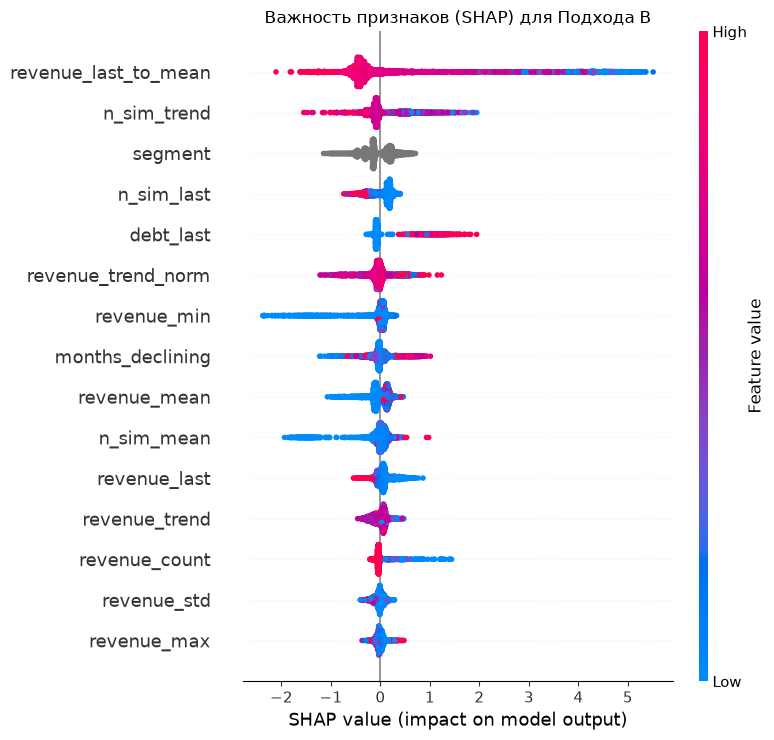


🔍 Разбор клиентов из топа риска:

--- Клиент CL035584 ---
  Сегмент: крупный бизнес
  Продукт: мобильная связь
  Предсказанная вероятность оттока: 0.9984
  Топ-5 факторов:
    - revenue_last_to_mean: ↑ повышает риск (вклад: 5.1315)
    - n_sim_trend: ↑ повышает риск (вклад: 1.4350)
    - debt_last: ↑ повышает риск (вклад: 1.2226)
    - months_declining: ↑ повышает риск (вклад: 0.7663)
    - revenue_trend_norm: ↑ повышает риск (вклад: 0.7605)

--- Клиент CL023056 ---
  Сегмент: малый бизнес
  Продукт: интернет
  Предсказанная вероятность оттока: 0.9969
  Топ-5 факторов:
    - revenue_last_to_mean: ↑ повышает риск (вклад: 4.6190)
    - debt_last: ↑ повышает риск (вклад: 1.0820)
    - n_sim_trend: ↑ повышает риск (вклад: 1.0750)
    - months_declining: ↑ повышает риск (вклад: 0.8404)
    - segment: ↑ повышает риск (вклад: 0.5907)


In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
from catboost import CatBoostClassifier, Pool

print("ИНТЕРПРЕТАЦИЯ: SHAP-анализ модели Подхода B")

#берём подвыборку для скорости (3000 строк)
shap_sample = test.sample(n=3000, random_state=42)

#обучаем модель на полных train данных для SHAP
X_train_full = train[feature_cols_B]
y_train_full = train['target']

train_pool_full = Pool(data=X_train_full, label=y_train_full, cat_features=cat_cols_B)

model_shap = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    verbose=0,
    early_stopping_rounds=100
)
model_shap.fit(train_pool_full)

#создаём SHAP explainer
print("Инициализация SHAP TreeExplainer...")
explainer = shap.TreeExplainer(model_shap)

#считаем SHAP-значения для подвыборки
print("Расчёт SHAP-значений...")
X_shap = shap_sample[feature_cols_B]
shap_values_raw = explainer.shap_values(X_shap)

#страховка: для бинарной классификации CatBoost иногда возвращает список [класс 0, класс 1]
#нам нужен класс 1 (отток)
if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw[1]
else:
    shap_values = shap_values_raw

#summary plot — какие признаки важнее всего
print("\nSummary plot (топ-15 признаков):")
shap.summary_plot(shap_values, X_shap, max_display=15, show=False)
plt.title('Важность признаков (SHAP) для Подхода B')
plt.tight_layout()
plt.show()

#пазбор 1-2 клиентов из топа риска
print("\nРазбор клиентов из топа риска:")
shap_sample_copy = shap_sample.copy()
shap_sample_copy['pred'] = model_shap.predict_proba(X_shap)[:, 1]

top_risk = shap_sample_copy.nlargest(2, 'pred')
for idx, row in top_risk.iterrows():
    print(f"\n--- Клиент {row.get('client_id', 'N/A')} ---")
    print(f"Сегмент: {row['segment']}")
    print(f"Продукт: {row['product']}")
    print(f"Предсказанная вероятность оттока: {row['pred']:.4f}")
    
    #находим локальный индекс этой строки в нашей подвыборке
    local_idx = shap_sample.index.get_loc(idx)
    client_shap = shap_values[local_idx]
    
    #показываем топ-5 факторов, толкающих к оттоку
    top_features = pd.Series(client_shap, index=feature_cols_B).abs().nlargest(5)
    print(f"  Топ-5 факторов:")
    for feat in top_features.index:
        feat_idx = feature_cols_B.index(feat)
        shap_val = client_shap[feat_idx]
        direction = "↑ повышает риск" if shap_val > 0 else "↓ снижает риск"
        print(f"    - {feat}: {direction} (вклад: {shap_val:.4f})")